In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
best_model = joblib.load("../models/best_model.pkl")

print(type(best_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [3]:
X_test = joblib.load("../models/X_test.pkl")
y_test = joblib.load("../models/y_test.pkl")

print(X_test.shape)

(118108, 477)


In [4]:
explainer = shap.TreeExplainer(best_model)

In [5]:
shap_values = explainer(X_test)

In [13]:
sample_size = 5000

X_sample = X_test.sample(
    n=sample_size,
    random_state=42
)

shap_values = explainer(X_sample)

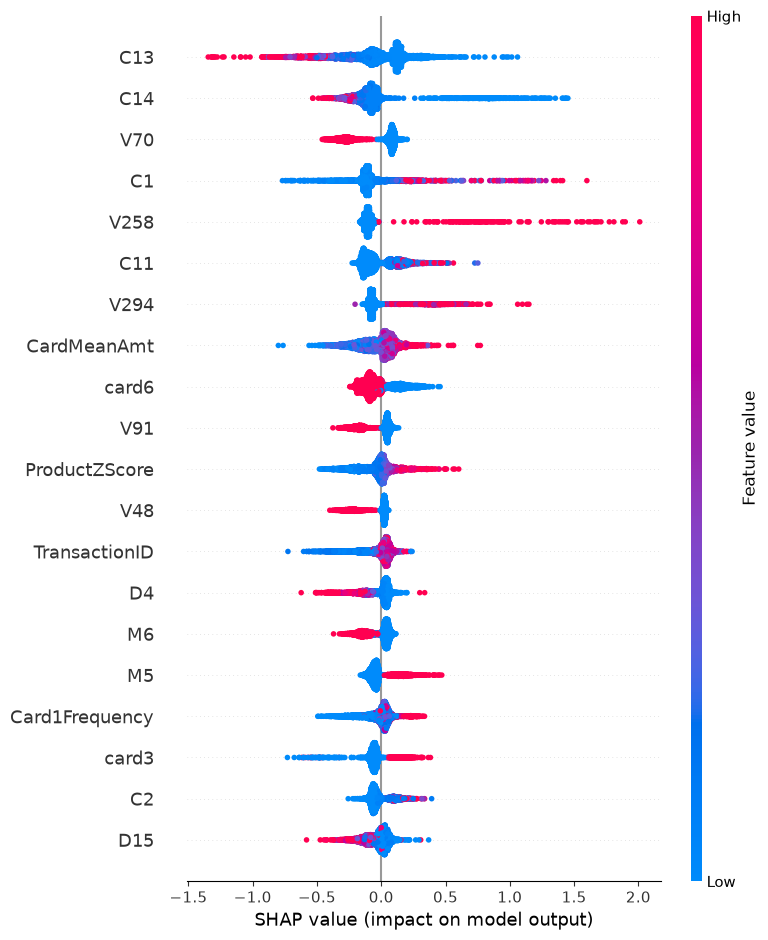

In [14]:
shap.summary_plot(
    shap_values,
    X_sample
)

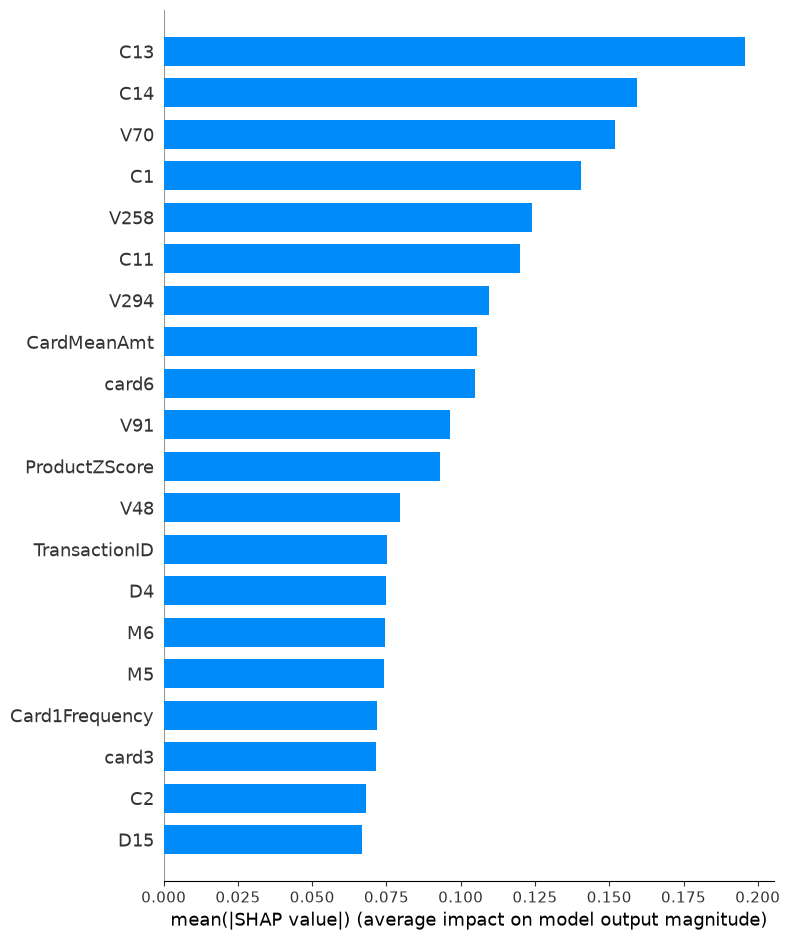

In [15]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

In [16]:
importance = np.abs(shap_values.values).mean(axis=0)

top_feature = X_sample.columns[
    np.argmax(importance)
]

print("Top Feature:", top_feature)

Top Feature: C13


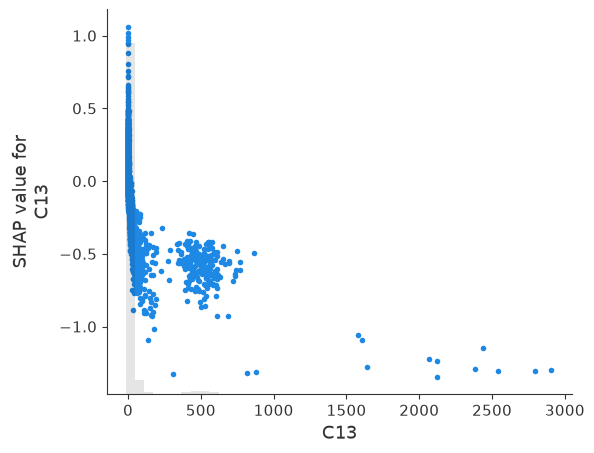

In [17]:
shap.plots.scatter(
    shap_values[:, top_feature]
)

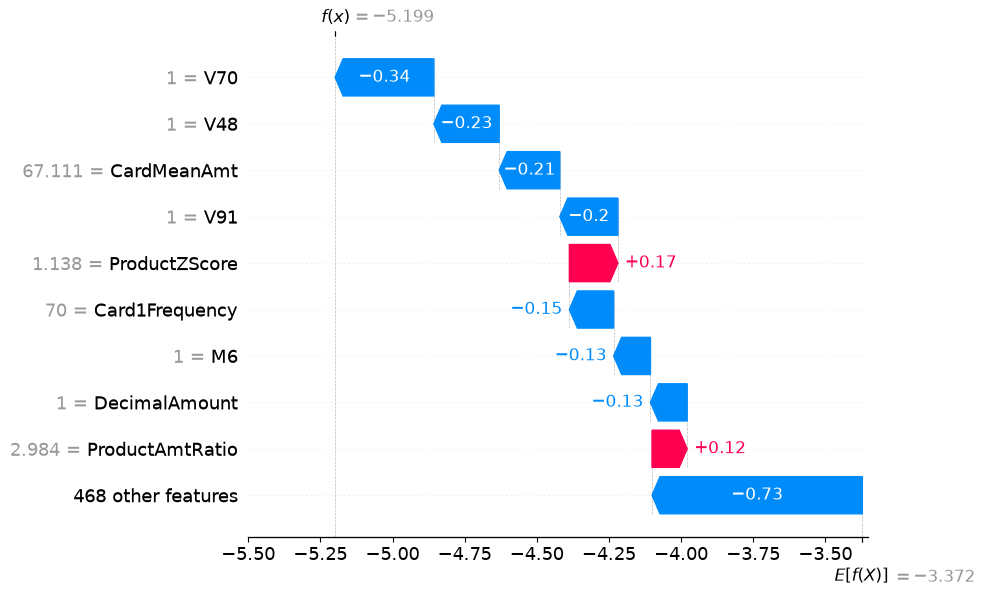

In [18]:
transaction = 0

shap.plots.waterfall(
    shap_values[transaction]
)

In [19]:
shap.initjs()

shap.plots.force(
    shap_values[transaction]
)

In [20]:
importance_df = pd.DataFrame({

    "Feature": X_sample.columns,

    "Mean_SHAP": np.abs(
        shap_values.values
    ).mean(axis=0)

})

importance_df = importance_df.sort_values(
    by="Mean_SHAP",
    ascending=False
)

importance_df.head(20)

,Feature,Mean_SHAP
27,C13,0.195699
28,C14,0.159219
121,V70,0.151842
15,C1,0.140568
309,V258,0.124137
25,C11,0.119905
345,V294,0.109373
432,CardMeanAmt,0.105482
9,card6,0.104775
142,V91,0.096323


In [21]:
importance_df.to_csv(
    "../models/shap_feature_importance.csv",
    index=False
)

print("Saved Successfully!")

Saved Successfully!
